# LSEG Data Pull

Kurzes Notebook zum Laden der vorbereiteten Euro500-Parquet-Tabellen.


## 0. Setup


In [30]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import lseg.data as ld

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 120)

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"


## 1. Parquet-Dateien laden


In [31]:
EURO500_PATH = DATA_DIR / "euro500.parquet"
EURO500_RETURNS_PATH = DATA_DIR / "euro500_returns.parquet"
DAILY_RETURNS_IN_INDEX_PATH = DATA_DIR / "daily_returns_euro500_in_index.parquet"

for p in [EURO500_PATH, EURO500_RETURNS_PATH, DAILY_RETURNS_IN_INDEX_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")

euro500 = pd.read_parquet(EURO500_PATH)
euro500_returns = pd.read_parquet(EURO500_RETURNS_PATH)
daily_returns_euro500_in_index = pd.read_parquet(DAILY_RETURNS_IN_INDEX_PATH)

print("Loaded:")
print("- euro500:", euro500.shape)
print("- euro500_returns:", euro500_returns.shape)
print("- daily_returns_euro500_in_index:", daily_returns_euro500_in_index.shape)


Loaded:
- euro500: (54000, 22)
- euro500_returns: (7016, 8)
- daily_returns_euro500_in_index: (3336230, 12)


## 2. Beta (täglich, rolling)

Markt: `market_return_ffmcap_capped80` aus `euro500_returns`.

### Definition der Beta-Schätzung

Wir schätzen ein **tägliches firmenspezifisches CAPM-Beta** als rolling Kennzahl je Firma `i`:

$$
\beta_{i,t} = \frac{\operatorname{Cov}_{W}(r_{i}, r_{m})}{\operatorname{Var}_{W}(r_{m})}
$$

mit:
- `r_i`: tägliche Firmenrendite (`ret`)
- `r_m`: tägliche Marktrendite (`market_ret_cap80` = `market_return_ffmcap_capped80`)
- `W`: rolling Fenster mit `BETA_WINDOW = 252` Handelstagen und `BETA_MIN_OBS = 126`

Implementierungsdetails (momentenbasiert, identisch zur Kovarianz/Varianz-Formel):

$$
\operatorname{Cov}_{W}(r_i,r_m)=E_W[r_i r_m]-E_W[r_i]E_W[r_m],
\qquad
\operatorname{Var}_{W}(r_m)=E_W[r_m^2]-E_W[r_m]^2
$$

Dann gilt in Code:
- `cov_im = mean_im - (mean_i * mean_m)`
- `var_m = mean_m2 - (mean_m ** 2)`
- `beta_capm_daily = cov_im / var_m` für `var_m > 0`, sonst `NaN`.

### QC-Filter (direkt auf `beta_capm_daily`)

Die gespeicherte Spalte `beta_capm_daily` ist bereits gefiltert mit:
- `n_firms_day >= 300`
- `var_m_roll >= 1e-6`
- `|beta_capm_daily| <= 3`

Bei Nichterfüllung wird **kein Datensatz gelöscht**; nur `beta_capm_daily` bleibt `NaN` (leer).


In [ ]:
MARKET_COL = "market_return_ffmcap_capped80"
BETA_WINDOW = 252
BETA_MIN_OBS = 126

# QC parameter
MIN_FIRMS_DAY = 300
MIN_VAR_M_ROLL = 1e-6
MAX_ABS_BETA = 3.0

daily_returns = daily_returns_euro500_in_index.copy()
daily_returns["date"] = pd.to_datetime(daily_returns["date"], errors="coerce")
daily_returns["ret"] = pd.to_numeric(daily_returns["ret"], errors="coerce")

market_daily = euro500_returns[["date", MARKET_COL]].copy()
market_daily["date"] = pd.to_datetime(market_daily["date"], errors="coerce")
market_daily["market_ret_cap80"] = pd.to_numeric(market_daily[MARKET_COL], errors="coerce")
market_daily = market_daily[["date", "market_ret_cap80"]].drop_duplicates(subset=["date"])

daily_returns = daily_returns.merge(market_daily, on="date", how="left")
daily_returns = daily_returns.sort_values(["company_key", "date"]).reset_index(drop=True)

# Ensure firm_id exists (backward compatible with older daily_returns files).
if "firm_id" not in daily_returns.columns:
    fid = pd.Series(pd.NA, index=daily_returns.index, dtype="string")
    if "ISIN" in daily_returns.columns:
        v = daily_returns["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("ISIN:" + v)
    if "RIC_current" in daily_returns.columns:
        v = daily_returns["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)
    if "RIC" in daily_returns.columns:
        v = daily_returns["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)
    if "SEDOL" in daily_returns.columns:
        v = daily_returns["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("SEDOL:" + v)
    if "company_key" in daily_returns.columns:
        ck = daily_returns["company_key"].astype("string").str.strip()
        ck = ck.where(ck.notna() & (ck != ""), pd.NA)
        fid = fid.fillna(ck)
    daily_returns["firm_id"] = fid
else:
    daily_returns["firm_id"] = daily_returns["firm_id"].astype("string").str.strip()
    daily_returns.loc[daily_returns["firm_id"] == "", "firm_id"] = pd.NA

daily_returns["ret_x_m"] = daily_returns["ret"] * daily_returns["market_ret_cap80"]
daily_returns["mkt_sq"] = daily_returns["market_ret_cap80"] ** 2

g = daily_returns.groupby("company_key", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_m = mean_m2 - (mean_m ** 2)
daily_returns["var_m_roll"] = var_m

# Raw beta
daily_returns["beta_capm_daily"] = np.where(var_m > 0, cov_im / var_m, np.nan)

# Cross-sectional availability per day (for QC)
n_firms_day = (
    daily_returns.groupby("date", as_index=False)["company_key"]
    .nunique()
    .rename(columns={"company_key": "n_firms_day"})
)
daily_returns = daily_returns.merge(n_firms_day, on="date", how="left")

qc_ok = (
    (daily_returns["n_firms_day"] >= MIN_FIRMS_DAY)
    & (daily_returns["var_m_roll"] >= MIN_VAR_M_ROLL)
    & (daily_returns["beta_capm_daily"].abs() <= MAX_ABS_BETA)
)

# Keep rows; only beta becomes empty (NaN) if QC fails.
daily_returns["beta_capm_daily"] = daily_returns["beta_capm_daily"].where(qc_ok, np.nan)

daily_company_data = daily_returns[[
    "date",
    "quarter",
    "firm_id",
    "company_key",
    "ret",
    "market_ret_cap80",
    "beta_capm_daily",
]].copy()

DAILY_COMPANY_DATA_PATH = DATA_DIR / "daily_company_data.parquet"
daily_company_data.to_parquet(DAILY_COMPANY_DATA_PATH, index=False)

print("Saved:", DAILY_COMPANY_DATA_PATH)
print("Rows:", len(daily_company_data))
print("Date range:", daily_company_data["date"].min(), "to", daily_company_data["date"].max())
print("Beta non-null share (after QC):", round(daily_company_data["beta_capm_daily"].notna().mean(), 4))
daily_company_data.head()


## 2B. Beta-Analyse (Qualität der Schätzung)

Kurze Diagnostik zur Frage, wie stabil und erklärungskräftig die geschätzten Betas sind.


In [33]:
analysis_df = daily_company_data.copy()
analysis_df = analysis_df.sort_values(["company_key", "date"]).reset_index(drop=True)

analysis_df["ret"] = pd.to_numeric(analysis_df["ret"], errors="coerce")
analysis_df["market_ret_cap80"] = pd.to_numeric(analysis_df["market_ret_cap80"], errors="coerce")
analysis_df["beta_capm_daily"] = pd.to_numeric(analysis_df["beta_capm_daily"], errors="coerce")

# Implied fit quality: R² aus rolling corr² (pro Firma, selbes Fenster wie Beta).
analysis_df["ret_sq"] = analysis_df["ret"] ** 2
analysis_df["ret_x_m"] = analysis_df["ret"] * analysis_df["market_ret_cap80"]
analysis_df["mkt_sq"] = analysis_df["market_ret_cap80"] ** 2

g = analysis_df.groupby("company_key", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_i2 = g["ret_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_i = mean_i2 - (mean_i ** 2)
var_m = mean_m2 - (mean_m ** 2)
den = np.sqrt(var_i * var_m)
corr_im = np.where(den > 0, cov_im / den, np.nan)
analysis_df["r2_capm_daily"] = np.clip(corr_im ** 2, 0, 1)

analysis_df["ret_hat"] = analysis_df["beta_capm_daily"] * analysis_df["market_ret_cap80"]
analysis_df["resid"] = analysis_df["ret"] - analysis_df["ret_hat"]
analysis_df["abs_err"] = (analysis_df["resid"]).abs()

n_firms_day = (
    analysis_df.groupby("date", as_index=False)["company_key"]
    .nunique()
    .rename(columns={"company_key": "n_firms_day"})
)
analysis_df = analysis_df.merge(n_firms_day, on="date", how="left")

summary = pd.DataFrame([
    {
        "rows": len(analysis_df),
        "companies": analysis_df["company_key"].nunique(),
        "beta_non_null_share": analysis_df["beta_capm_daily"].notna().mean(),
        "r2_non_null_share": analysis_df["r2_capm_daily"].notna().mean(),
        "beta_median": analysis_df["beta_capm_daily"].median(),
        "beta_p10": analysis_df["beta_capm_daily"].quantile(0.10),
        "beta_p90": analysis_df["beta_capm_daily"].quantile(0.90),
        "r2_median": analysis_df["r2_capm_daily"].median(),
        "r2_p90": analysis_df["r2_capm_daily"].quantile(0.90),
        "mae": analysis_df["abs_err"].mean(),
    }
])

print("Gesamt-Diagnostik:")
display(summary)

by_company = (
    analysis_df.groupby("company_key", as_index=False)
    .agg(
        n_obs=("beta_capm_daily", "size"),
        beta_non_null=("beta_capm_daily", lambda s: s.notna().sum()),
        beta_median=("beta_capm_daily", "median"),
        beta_std=("beta_capm_daily", "std"),
        r2_median=("r2_capm_daily", "median"),
        mae=("abs_err", "mean"),
    )
)
by_company["beta_availability"] = np.where(by_company["n_obs"] > 0, by_company["beta_non_null"] / by_company["n_obs"], np.nan)

print("Schwächste 10 Firmen nach medianem R²:")
display(by_company.sort_values(["r2_median", "beta_availability"]).head(10))

print("Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):")
display(by_company.sort_values(["r2_median", "beta_availability"], ascending=[False, False]).head(10))


Gesamt-Diagnostik:


,rows,companies,beta_non_null_share,r2_non_null_share,beta_median,beta_p10,beta_p90,r2_median,r2_p90,mae
0,3336230,1621,0.941129,0.944566,0.752335,0.184144,1.376809,0.165873,0.461036,0.012954


Schwächste 10 Firmen nach medianem R²:


,company_key,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
505,ISIN:ES0137998516,402,275,0.193686,0.182793,0.000020,0.033732,0.684080
1225,ISIN:IT0005611642,192,63,-0.004625,0.023550,0.000037,0.024027,0.328125
1401,ISIN:NL00150006Z9,193,68,0.015531,0.023501,0.000064,0.013889,0.352332
674,ISIN:FR0000039026,145,17,-0.029355,0.019121,0.000167,0.013324,0.117241
621,ISIN:FI0009900385,196,70,0.020625,0.054735,0.000201,0.026956,0.357143
389,ISIN:DE000A2YNT30,158,33,-0.068520,0.038593,0.000202,0.022704,0.208861
616,ISIN:FI0009800296,218,90,0.043602,0.102685,0.000224,0.024781,0.412844
7,ISIN:AT0000640552,1147,1021,-0.000448,0.090612,0.000268,0.013315,0.890148
240,ISIN:DE0006044001,240,112,0.036427,0.052891,0.000288,0.021753,0.466667
244,ISIN:DE0006069008,129,3,0.032868,0.000062,0.000302,0.000196,0.023256


Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):


,company_key,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
295,ISIN:DE0007236101,6824,6694,1.342578,0.214515,0.652325,0.008077,0.980950
398,ISIN:DE000BASF111,3900,3775,1.232545,0.106119,0.583791,0.007777,0.967949
827,ISIN:FR0000121972,6870,6706,1.328773,0.332003,0.578835,0.009526,0.976128
815,ISIN:FR0000121014,6935,6770,1.237600,0.210640,0.578045,0.008871,0.976208
1123,ISIN:IT0001407847,1392,1262,1.230234,0.155104,0.556080,0.010444,0.906609
831,ISIN:FR0000125007,6872,6708,1.360069,0.348926,0.554577,0.009845,0.976135
177,ISIN:DE0005151005,2987,2857,1.064615,0.289596,0.547894,0.00958,0.956478
798,ISIN:FR0000120073,6935,6770,0.927347,0.201670,0.542602,0.007248,0.976208
556,ISIN:ES0178430E18,6832,6684,1.003315,0.346600,0.541915,0.008546,0.978337
1102,ISIN:IT0001137311,504,379,1.044522,0.278702,0.538043,0.01315,0.751984


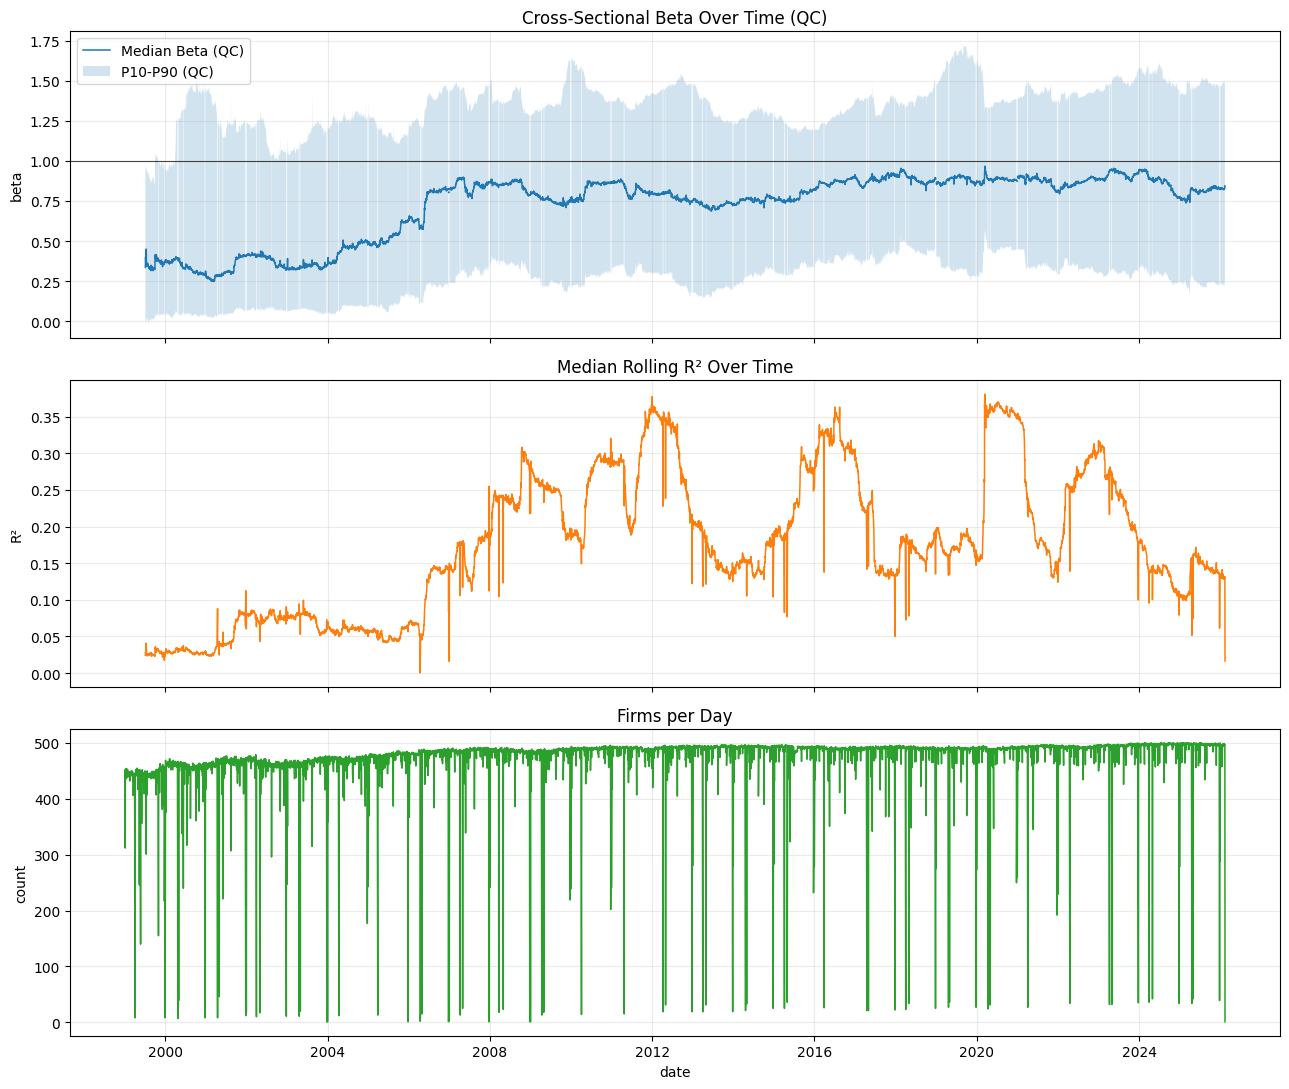

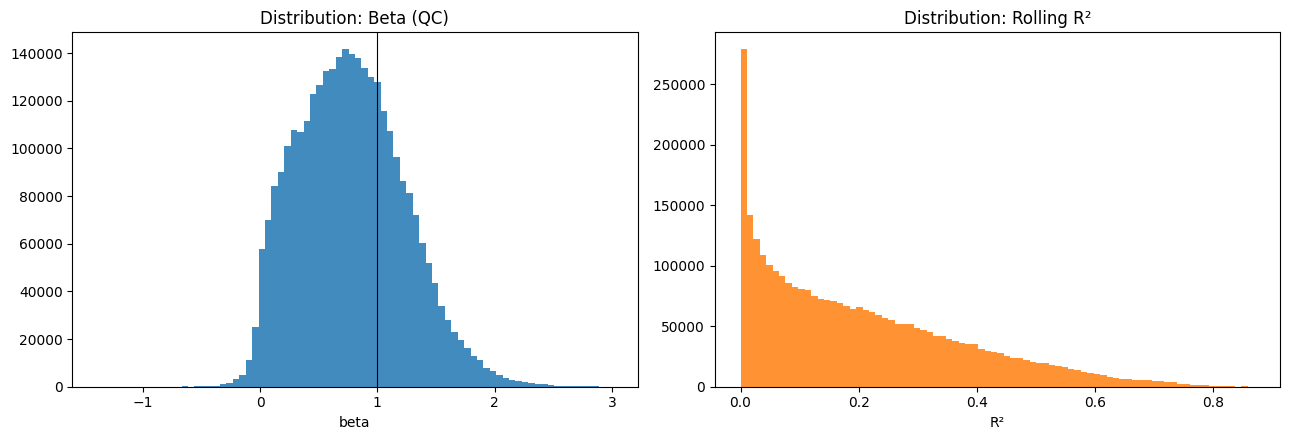

In [34]:
import matplotlib.pyplot as plt

plot_df = analysis_df.dropna(subset=["date"]).copy()

beta_daily_stats = (
    plot_df.groupby("date", as_index=False)
    .agg(
        beta_median=("beta_capm_daily", "median"),
        beta_p10=("beta_capm_daily", lambda s: s.quantile(0.10)),
        beta_p90=("beta_capm_daily", lambda s: s.quantile(0.90)),
        r2_median=("r2_capm_daily", "median"),
        n_firms=("n_firms_day", "max"),
    )
    .sort_values("date")
)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(beta_daily_stats["date"], beta_daily_stats["beta_median"], lw=1.1, label="Median Beta (QC)")
axes[0].fill_between(
    beta_daily_stats["date"],
    beta_daily_stats["beta_p10"],
    beta_daily_stats["beta_p90"],
    alpha=0.2,
    label="P10-P90 (QC)",
)
axes[0].axhline(1.0, color="black", lw=0.8, alpha=0.7)
axes[0].set_title("Cross-Sectional Beta Over Time (QC)")
axes[0].set_ylabel("beta")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(beta_daily_stats["date"], beta_daily_stats["r2_median"], color="tab:orange", lw=1.1)
axes[1].set_title("Median Rolling R² Over Time")
axes[1].set_ylabel("R²")
axes[1].grid(alpha=0.25)

axes[2].plot(beta_daily_stats["date"], beta_daily_stats["n_firms"], color="tab:green", lw=1.1)
axes[2].set_title("Firms per Day")
axes[2].set_ylabel("count")
axes[2].set_xlabel("date")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(plot_df["beta_capm_daily"].dropna(), bins=80, color="tab:blue", alpha=0.85)
axes[0].axvline(1.0, color="black", lw=0.8)
axes[0].set_title("Distribution: Beta (QC)")
axes[0].set_xlabel("beta")

axes[1].hist(plot_df["r2_capm_daily"].dropna(), bins=80, color="tab:orange", alpha=0.85)
axes[1].set_title("Distribution: Rolling R²")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()


## 3. EPS Forecasts FY1–FY5 für EURO500 laden

Ziel:
- Für jeden Eintrag in `euro500` einen As-of EPS-Forecast ziehen
- Horizont `FY1` bis `FY5`
- Ergebnis als `EURO500_EPS.parquet` mit je einer Spalte pro Forecast-Horizont


In [ ]:
# ------------------------------------------------------------
# Step 3 — Robust EPS Forecast Pull (FY1-FY5) with checkpoints
# ------------------------------------------------------------

HORIZONS = ["FY1", "FY2", "FY3", "FY4", "FY5"]
EPS_FIELDS = [f"TR.EPSMean(period={h})" for h in HORIZONS]
BATCH_SIZE = 100
FORCE_REFRESH_EPS = False
MAX_SPLIT_DEPTH = 10

EURO500_EPS_PATH = DATA_DIR / "EURO500_EPS.parquet"
EPS_CKPT_DIR = DATA_DIR / "eps_checkpoints"
EPS_CKPT_DIR.mkdir(parents=True, exist_ok=True)
EPS_BAD_RICS_LOG = DATA_DIR / "eps_bad_rics.csv"


def _clean_str(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    x = x.where(x.notna() & (x != ""), pd.NA)
    return x


def _asof_from_euro500(df: pd.DataFrame) -> pd.Series:
    if "date" in df.columns:
        return pd.to_datetime(df["date"], errors="coerce").dt.normalize()
    if "formation_date" in df.columns:
        return pd.to_datetime(df["formation_date"], errors="coerce").dt.normalize()
    if "effective_date" in df.columns:
        return pd.to_datetime(df["effective_date"], errors="coerce").dt.normalize()
    raise ValueError("No usable date column found in euro500 (expected date/formation_date/effective_date).")


def _chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i : i + n]


def _ckpt_path(asof: pd.Timestamp, batch_ix: int) -> Path:
    return EPS_CKPT_DIR / f"eps_{asof.strftime('%Y%m%d')}_batch_{batch_ix:04d}.parquet"


def _atomic_to_parquet(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_parquet(tmp, index=False)
    tmp.replace(path)


def _append_bad_rics(bad_list: list[str], asof: pd.Timestamp, reason: str):
    if not bad_list:
        return
    d = pd.DataFrame({"pull_ric": bad_list, "asof_date": pd.to_datetime(asof), "reason": reason})
    if EPS_BAD_RICS_LOG.exists():
        old = pd.read_csv(EPS_BAD_RICS_LOG)
        d = pd.concat([old, d], ignore_index=True)
        d = d.drop_duplicates(subset=["pull_ric", "asof_date", "reason"])
    d.to_csv(EPS_BAD_RICS_LOG, index=False)


def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [
            " | ".join([str(v) for v in tup if v is not None]).strip()
            for tup in x.columns
        ]
    else:
        x.columns = [str(c).strip() for c in x.columns]
    return x


def _fetch_eps_for_batch(
    batch: list[str],
    asof_str: str,
    asof_date: pd.Timestamp,
    max_split_depth: int = 10,
) -> tuple[pd.DataFrame, list[str]]:
    """
    Fetch EPSMean forecasts for a batch.
    On failure, recursively split batch until success or bad single RIC is identified.
    Returns: (raw_df, bad_rics)
    """
    if not batch:
        return pd.DataFrame(), []

    params = {"SDate": asof_str, "EDate": asof_str}

    try:
        raw = ld.get_data(universe=batch, fields=EPS_FIELDS, parameters=params)
        if raw is None or len(raw) == 0:
            return pd.DataFrame(), []
        return pd.DataFrame(raw), []
    except Exception:
        if len(batch) == 1 or max_split_depth <= 0:
            return pd.DataFrame(), [batch[0]]

        mid = len(batch) // 2
        left = batch[:mid]
        right = batch[mid:]

        df_l, bad_l = _fetch_eps_for_batch(left, asof_str, asof_date, max_split_depth=max_split_depth - 1)
        df_r, bad_r = _fetch_eps_for_batch(right, asof_str, asof_date, max_split_depth=max_split_depth - 1)

        out = []
        if df_l is not None and not df_l.empty:
            out.append(df_l)
        if df_r is not None and not df_r.empty:
            out.append(df_r)

        df_out = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
        return df_out, (bad_l + bad_r)


def _standardize_eps_df(df: pd.DataFrame, asof_date: pd.Timestamp) -> pd.DataFrame:
    """
    Standardize get_data result into columns:
    pull_ric, asof_date, EPS_FY1..EPS_FY5

    Robust to:
    - MultiIndex columns
    - duplicate column names
    - column name variants from LSEG
    """
    out_cols = ["pull_ric", "asof_date"] + [f"EPS_{h}" for h in HORIZONS]
    if df is None or getattr(df, "empty", True):
        return pd.DataFrame(columns=out_cols)

    x = _flatten_columns(df)

    # instrument / ric column
    ric_col = None
    for c in x.columns:
        cl = c.lower()
        if cl in {"instrument", "ric"}:
            ric_col = c
            break
    if ric_col is None:
        for c in x.columns:
            cl = c.lower()
            if "instrument" in cl or cl.endswith("ric"):
                ric_col = c
                break
    if ric_col is None:
        ric_col = x.columns[0]

    std = pd.DataFrame({
        "pull_ric": x[ric_col].astype("string").str.strip(),
        "asof_date": pd.to_datetime(asof_date),
    })

    def _as_series(v):
        if isinstance(v, pd.DataFrame):
            return v.iloc[:, 0]
        return v

    # map each horizon by searching column names
    for h in HORIZONS:
        target = f"EPS_{h}"
        col_match = None
        for c in x.columns:
            uc = c.upper()
            if ("EPS" in uc) and ("MEAN" in uc) and (h in uc):
                col_match = c
                break
        if col_match is None:
            for c in x.columns:
                uc = c.upper()
                if ("EPS" in uc) and (h in uc):
                    col_match = c
                    break

        if col_match is None:
            std[target] = np.nan
        else:
            s = _as_series(x[col_match])
            std[target] = pd.to_numeric(s, errors="coerce")

    std["pull_ric"] = _clean_str(std["pull_ric"])
    std = std.dropna(subset=["pull_ric"]).drop_duplicates(subset=["pull_ric", "asof_date"], keep="last")

    return std[out_cols]


# ------------------------------------------------------------
# Build request universe from euro500
# ------------------------------------------------------------
euro500_eps = euro500.copy()
euro500_eps["asof_date"] = _asof_from_euro500(euro500_eps)

if "RIC_current" in euro500_eps.columns:
    ric_current = _clean_str(euro500_eps["RIC_current"])
else:
    ric_current = pd.Series(pd.NA, index=euro500_eps.index, dtype="string")

if "RIC" in euro500_eps.columns:
    ric_raw = _clean_str(euro500_eps["RIC"])
else:
    ric_raw = pd.Series(pd.NA, index=euro500_eps.index, dtype="string")

euro500_eps["pull_ric"] = ric_current.fillna(ric_raw)

req = (
    euro500_eps[["asof_date", "pull_ric"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print("EPS request rows (unique asof_date x pull_ric):", len(req))
print("As-of date range:", req["asof_date"].min(), "to", req["asof_date"].max())


# ------------------------------------------------------------
# Pull with checkpoints + recursive split
# ------------------------------------------------------------
rows = []

by_date = (
    req.groupby("asof_date", sort=True)["pull_ric"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .reset_index()
)

ld.open_session()
try:
    for d_ix, r in by_date.iterrows():
        asof_date = pd.to_datetime(r["asof_date"])
        asof_str = asof_date.strftime("%Y-%m-%d")
        rics = list(r["pull_ric"])

        print(f"[{d_ix+1}/{len(by_date)}] AsOf {asof_str} | RICs={len(rics)}")

        for b_ix, batch in enumerate(_chunks(rics, BATCH_SIZE), start=1):
            ck = _ckpt_path(asof_date, b_ix)

            if ck.exists() and not FORCE_REFRESH_EPS:
                try:
                    part = pd.read_parquet(ck)
                    rows.append(part)
                    continue
                except Exception:
                    try:
                        ck.unlink()
                    except Exception:
                        pass

            raw_df, bad = _fetch_eps_for_batch(
                batch=batch,
                asof_str=asof_str,
                asof_date=asof_date,
                max_split_depth=MAX_SPLIT_DEPTH,
            )

            if bad:
                _append_bad_rics(bad, asof=asof_date, reason="get_data_failed_recursive_split")

            part = _standardize_eps_df(raw_df, asof_date=asof_date)

            # write checkpoint even if empty to avoid endless retries
            _atomic_to_parquet(part, ck)
            rows.append(part)

finally:
    ld.close_session()


# ------------------------------------------------------------
# Consolidate + merge back to euro500 rows
# ------------------------------------------------------------
out_cols = ["pull_ric", "asof_date"] + [f"EPS_{h}" for h in HORIZONS]
if rows:
    eps_panel = pd.concat(rows, ignore_index=True)
else:
    eps_panel = pd.DataFrame(columns=out_cols)

eps_panel["asof_date"] = pd.to_datetime(eps_panel.get("asof_date"), errors="coerce")
eps_panel = eps_panel[eps_panel["asof_date"].notna()].copy()

eps_panel = (
    eps_panel.sort_values(["pull_ric", "asof_date"])
    .drop_duplicates(["pull_ric", "asof_date"], keep="last")
    .reset_index(drop=True)
)

euro500_eps = euro500_eps.merge(eps_panel, on=["pull_ric", "asof_date"], how="left")

euro500_eps.to_parquet(EURO500_EPS_PATH, index=False)

print("Saved:", EURO500_EPS_PATH)
print("Rows:", len(euro500_eps))
print("Unique pull_ric:", euro500_eps["pull_ric"].nunique(dropna=True))
for h in HORIZONS:
    c = f"EPS_{h}"
    miss = int(euro500_eps[c].isna().sum()) if c in euro500_eps.columns else -1
    print(f"Missing {c}: {miss}")
print(f"[INFO] Bad RIC log (if any): {EPS_BAD_RICS_LOG}")
